In [114]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sre_constants import FAILURE
import matplotlib.gridspec as gridspec
from scipy import stats


In [115]:
df = pd.read_csv('../data/raw_data/predictive_maintenance_data.csv')

In [116]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [117]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [118]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [119]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

### Null values

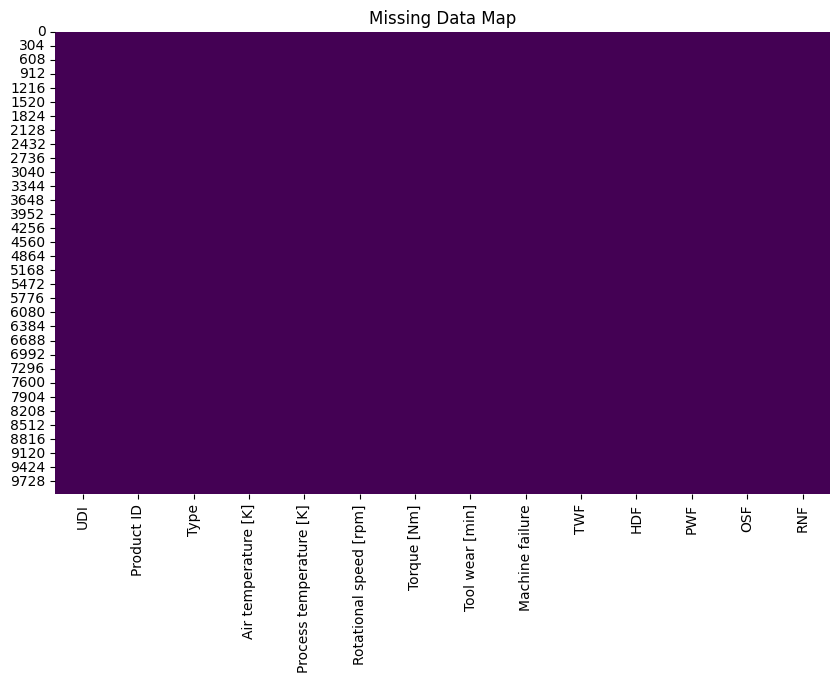

In [120]:
# check for missing values
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Data Map')
plt.show()

In [121]:
# remove brackets and units from column names
df.columns = df.columns.str.replace(r'\[.*\]', '', regex=True).str.strip()

# Rename columns using string
df.columns = df.columns.str.strip().str.replace(' ', '_').str.replace('[^A-Za-z0-9_]+', '')

# all in lowercase
df.columns = df.columns.str.lower()

In [122]:
df.columns

Index(['udi', 'product_id', 'type', 'air_temperature', 'process_temperature',
       'rotational_speed', 'torque', 'tool_wear', 'machine_failure', 'twf',
       'hdf', 'pwf', 'osf', 'rnf'],
      dtype='object')

### Feature Correlation

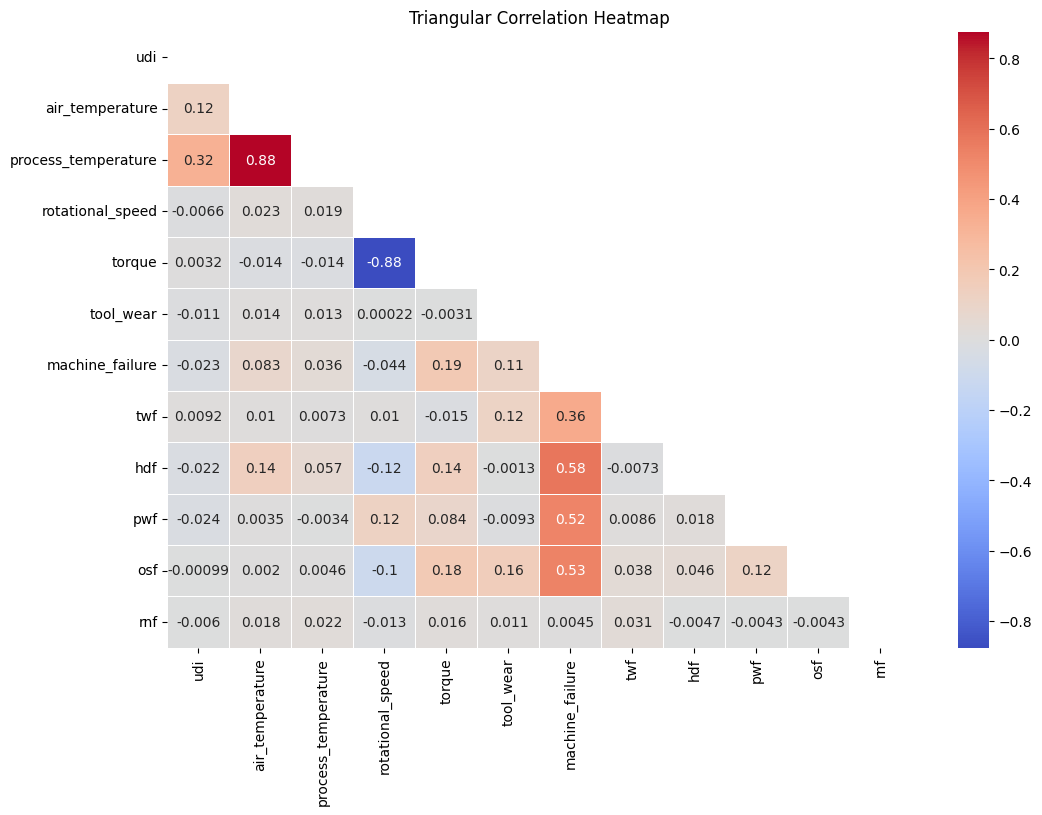

In [123]:
numeric_cols = df.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(df[numeric_cols].corr(), dtype=bool))
sns.heatmap(df[numeric_cols].corr(), mask=mask, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Triangular Correlation Heatmap')
plt.show()

## Target Analysis

In [124]:
FAILURE_COLS = ['twf', 'hdf', 'pwf', 'osf', 'rnf']
SENSOR_COLS  = ['air_temperature', 'process_temperature',
                'rotational_speed', 'torque', 'tool_wear']
FAILURE_PALETTE = dict(zip(FAILURE_COLS,
                           sns.color_palette('Set2', len(FAILURE_COLS))))

/tmp/ipykernel_179522/3274449271.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='machine_failure', data=df, palette='Set2')


Text(0.5, 1.0, 'Class Distribution of Failure')

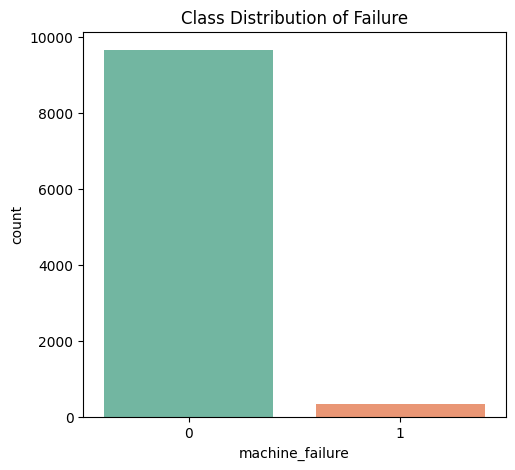

In [125]:
# Check for class imbalance
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(x='machine_failure', data=df, palette='Set2')
plt.title('Class Distribution of Failure')

/tmp/ipykernel_179522/2455771778.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=failure_counts.index, y=failure_counts.values, palette=FAILURE_PALETTE)


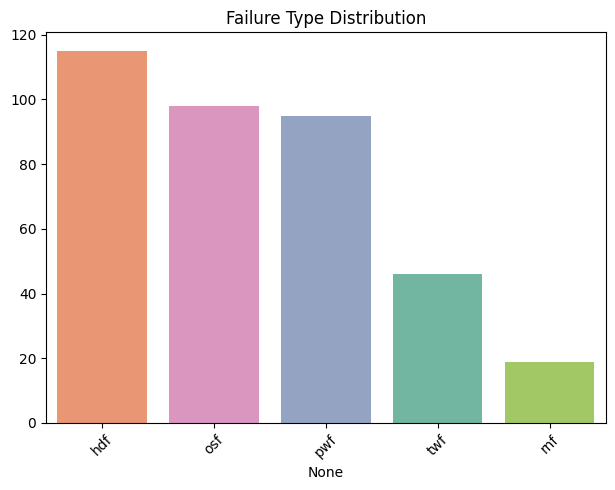

In [126]:
# Failure type

failure_counts = df[FAILURE_COLS].sum().sort_values(ascending=False)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 2)
sns.barplot(x=failure_counts.index, y=failure_counts.values, palette=FAILURE_PALETTE)
plt.title('Failure Type Distribution')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Univariate Sensory Analysis

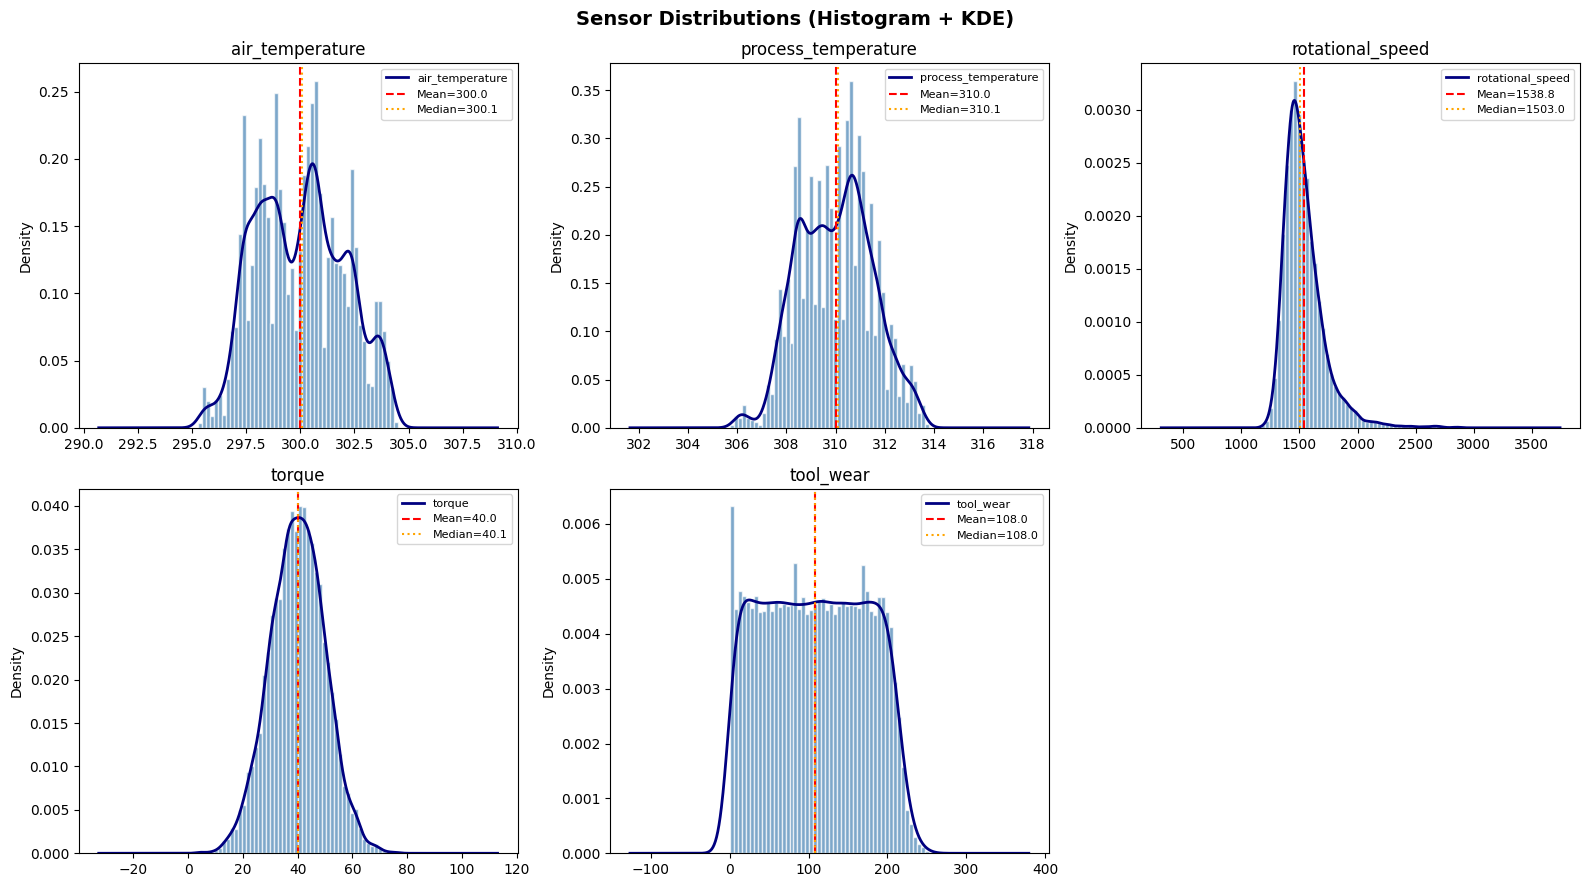

In [127]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(SENSOR_COLS):
    ax = axes[i]
    data = df[col]
    ax.hist(data, bins=50, color='steelblue', alpha=0.7, edgecolor='white', density=True)
    data.plot.kde(ax=ax, color='navy', linewidth=2)
    ax.axvline(data.mean(),  color='red',    linestyle='--', linewidth=1.5, label=f'Mean={data.mean():.1f}')
    ax.axvline(data.median(),color='orange', linestyle=':',  linewidth=1.5, label=f'Median={data.median():.1f}')
    ax.set_title(col)
    ax.legend(fontsize=8)
    ax.set_ylabel('Density')

# Remove empty subplot
fig.delaxes(axes[-1])
plt.suptitle('Sensor Distributions (Histogram + KDE)', fontsize=14, fontweight='bold')
plt.tight_layout()
#plt.savefig('plots/03_sensor_distributions.png', bbox_inches='tight')
plt.show()

In [129]:
# ── Skewness & Kurtosis table ────────────────────────────────────────────────
stats_tbl = pd.DataFrame({
    'Mean'     : df[SENSOR_COLS].mean(),
    'Std'      : df[SENSOR_COLS].std(),
    'Skewness' : df[SENSOR_COLS].skew(),
    'Kurtosis' : df[SENSOR_COLS].kurt(),
    'Min'      : df[SENSOR_COLS].min(),
    'Max'      : df[SENSOR_COLS].max(),
})
stats_tbl.style.background_gradient(cmap='RdYlGn', subset=['Skewness','Kurtosis'])

,Mean,Std,Skewness,Kurtosis,Min,Max
air_temperature,300.004930,2.000259,0.114274,-0.835962,295.300000,304.500000
process_temperature,310.005560,1.483734,0.015027,-0.499734,305.700000,313.800000
rotational_speed,1538.776100,179.284096,1.993171,7.392945,1168.000000,2886.000000
torque,39.986910,9.968934,-0.009517,-0.013241,3.800000,76.600000
tool_wear,107.951000,63.654147,0.027292,-1.166737,0.000000,253.000000


### Bi-Variate Relationships

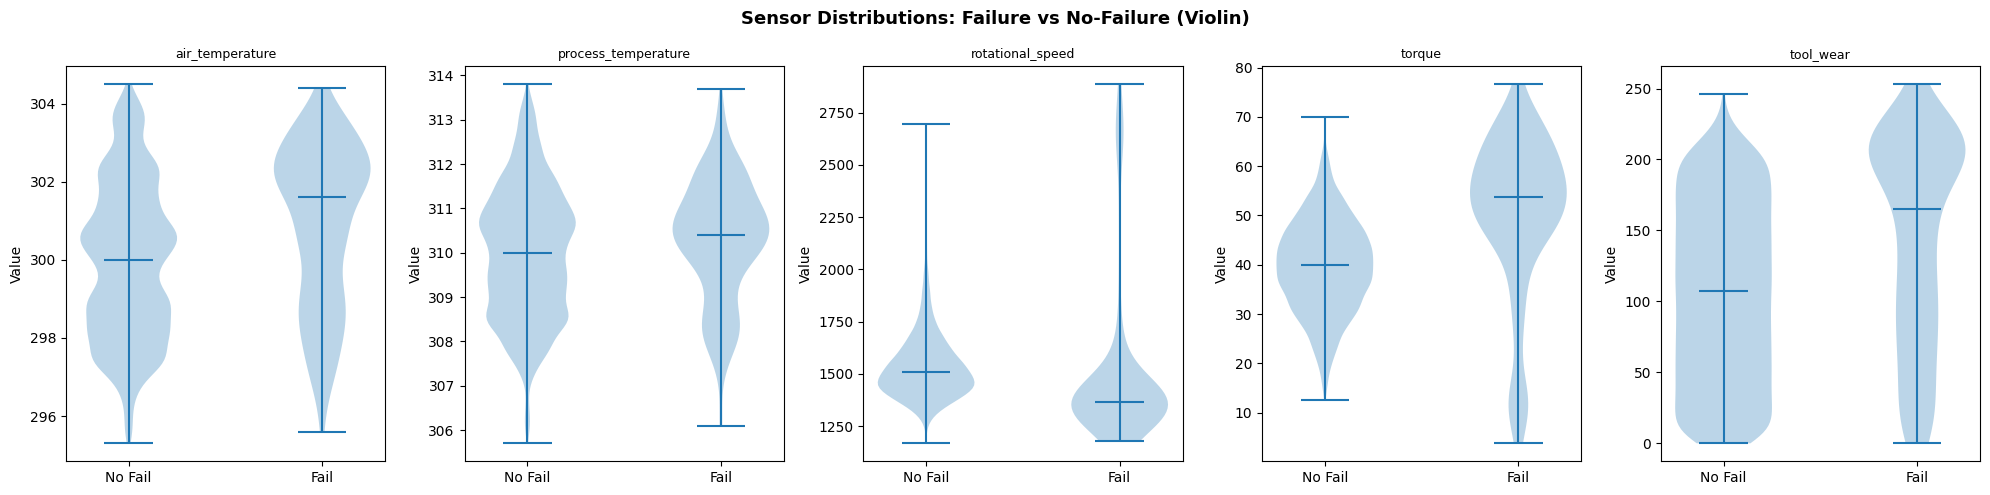

In [130]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, col in enumerate(SENSOR_COLS):
    ax = axes[i]
    groups = [df.loc[df['machine_failure']==0, col],
              df.loc[df['machine_failure']==1, col]]
    ax.violinplot(groups, positions=[0, 1], showmedians=True)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['No Fail', 'Fail'])
    ax.set_title(col.split('[')[0].strip(), fontsize=9)
    ax.set_ylabel('Value')

plt.suptitle('Sensor Distributions: Failure vs No-Failure (Violin)', fontsize=13, fontweight='bold')
plt.tight_layout()
#plt.savefig('plots/04_sensor_vs_failure_violin.png', bbox_inches='tight')
plt.show()

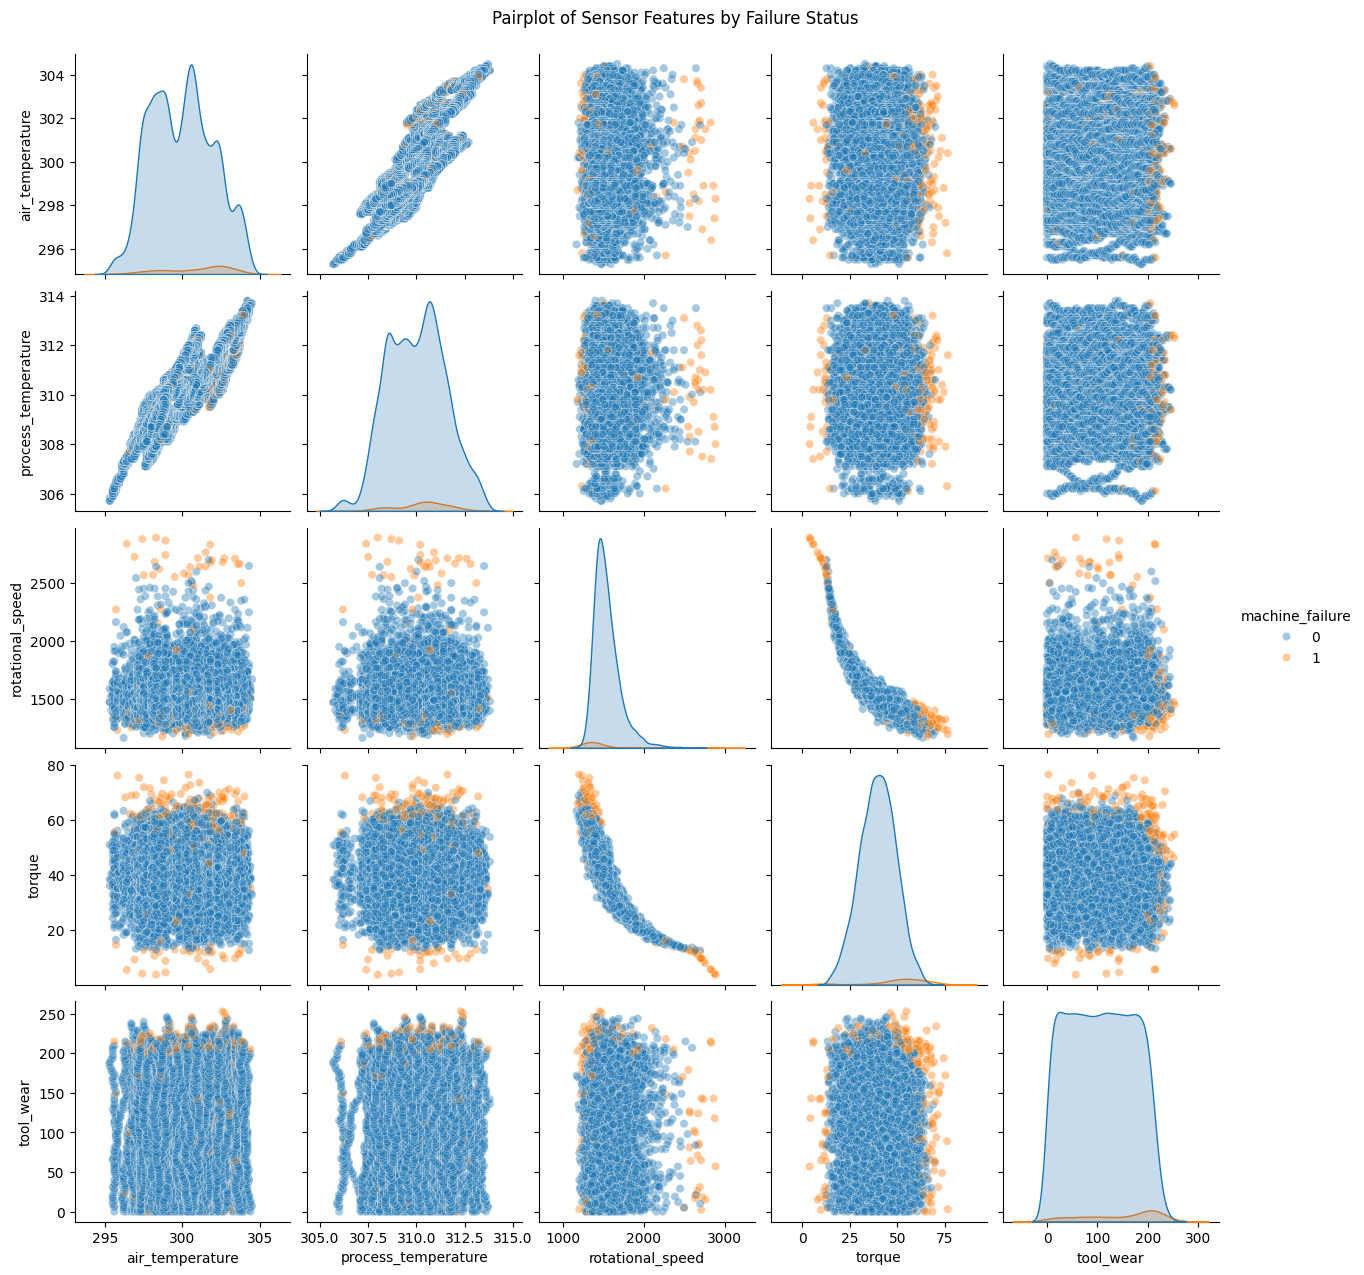

In [131]:
# Focus on the core sensor features
sns.pairplot(df, vars=SENSOR_COLS, hue='machine_failure', diag_kind='kde', plot_kws={'alpha':0.4})
plt.suptitle("Pairplot of Sensor Features by Failure Status", y=1.02)
plt.show()

### Machine Type Analysis

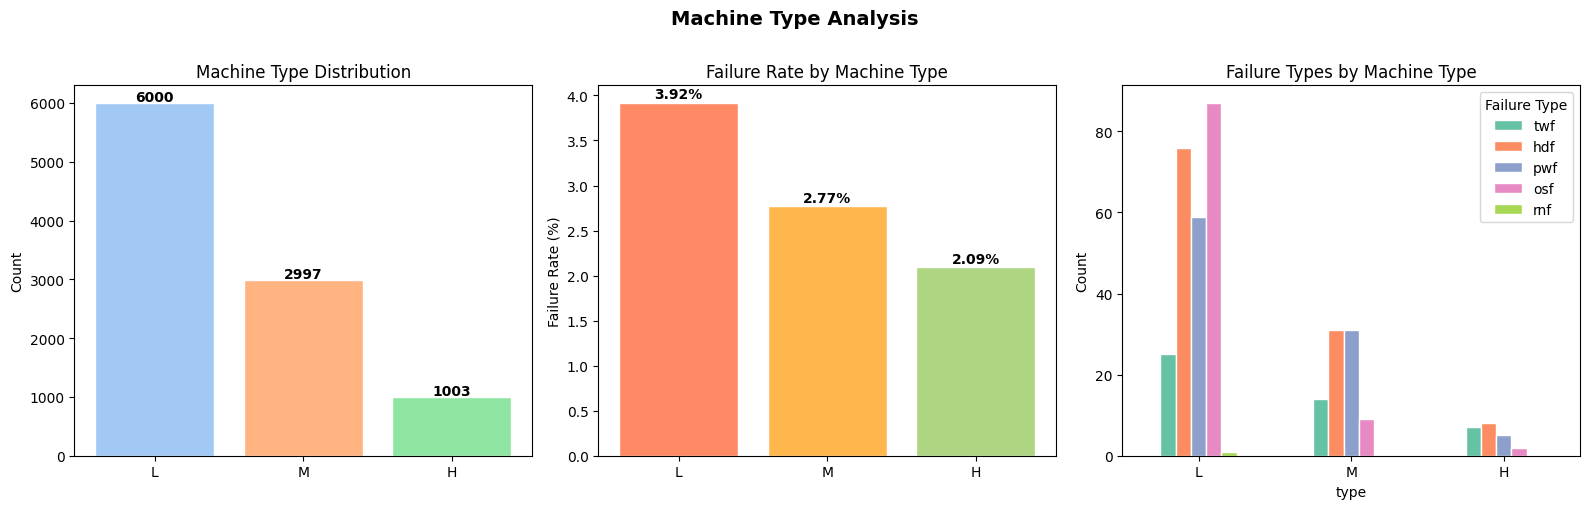

In [132]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 6a — Type distribution
type_counts = df['type'].value_counts()
axes[0].bar(type_counts.index, type_counts.values,
            color=sns.color_palette('pastel', 3), edgecolor='white')
for i, (t, v) in enumerate(type_counts.items()):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')
axes[0].set_title('Machine Type Distribution')
axes[0].set_ylabel('Count')

# 6b — Failure rate per type
fail_rate = df.groupby('type')['machine_failure'].mean() * 100
fail_rate = fail_rate.reindex(['L','M','H'])
axes[1].bar(fail_rate.index, fail_rate.values,
            color=['#FF8A65','#FFB74D','#AED581'], edgecolor='white')
for i, v in enumerate(fail_rate.values):
    axes[1].text(i, v + 0.05, f'{v:.2f}%', ha='center', fontweight='bold')
axes[1].set_title('Failure Rate by Machine Type')
axes[1].set_ylabel('Failure Rate (%)')

# 6c — Failure type breakdown by machine type
ft_by_type = df[df['machine_failure']==1].groupby('type')[FAILURE_COLS].sum()
ft_by_type.reindex(['L','M','H']).plot(kind='bar', ax=axes[2],
                                        color=list(FAILURE_PALETTE.values()),
                                        edgecolor='white', rot=0)
axes[2].set_title('Failure Types by Machine Type')
axes[2].set_ylabel('Count')
axes[2].legend(title='Failure Type', bbox_to_anchor=(1,1))

plt.suptitle('Machine Type Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
#plt.savefig('plots/07_machine_type_analysis.png', bbox_inches='tight')
plt.show()

### outlier detection

In [133]:
outlier_summary = {}
for col in SENSOR_COLS:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    outlier_summary[col] = {'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
                             'Lower fence': lo, 'Upper fence': hi,
                             'Outliers': n_out, 'Outlier %': n_out/len(df)*100}

out_df = pd.DataFrame(outlier_summary).T
print(out_df.round(3))

                         Q1      Q3    IQR  Lower fence  Upper fence  \
air_temperature       298.3   301.5    3.2       293.50       306.30   
process_temperature   308.8   311.1    2.3       305.35       314.55   
rotational_speed     1423.0  1612.0  189.0      1139.50      1895.50   
torque                 33.2    46.8   13.6        12.80        67.20   
tool_wear              53.0   162.0  109.0      -110.50       325.50   

                     Outliers  Outlier %  
air_temperature           0.0       0.00  
process_temperature       0.0       0.00  
rotational_speed        418.0       4.18  
torque                   69.0       0.69  
tool_wear                 0.0       0.00  


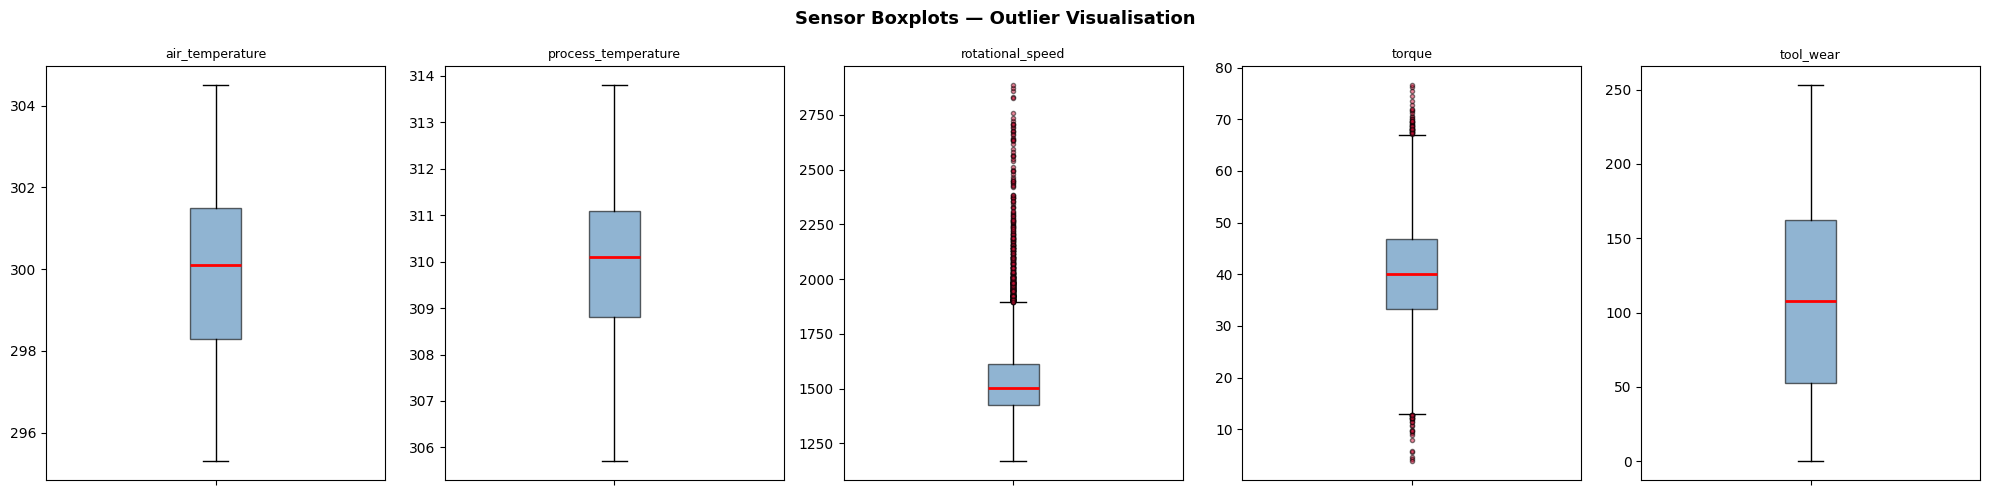

In [134]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for i, col in enumerate(SENSOR_COLS):
    ax = axes[i]
    ax.boxplot(df[col], vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6),
               medianprops=dict(color='red', linewidth=2),
               flierprops=dict(marker='o', markerfacecolor='crimson',
                               markersize=3, alpha=0.5))
    ax.set_title(col.split('[')[0].strip(), fontsize=9)
    ax.set_xticklabels([])

plt.suptitle('Sensor Boxplots — Outlier Visualisation', fontsize=13, fontweight='bold')
plt.tight_layout()
#plt.savefig('plots/08_outlier_boxplots.png', bbox_inches='tight')
plt.show()

## Feature Engineering

In [135]:
# Work on a copy 
df_eng = df.copy()

# Ordinal encode Type (L=0, M=1, H=2) as L<M<H
type_map = {'L': 0, 'M': 1, 'H': 2}
df_eng['type_enc'] = df_eng['type'].map(type_map)
print("Type encoding:", type_map)


Type encoding: {'L': 0, 'M': 1, 'H': 2}


In [136]:
# Temperature differential — proxy for thermal stress
df_eng['temp_diff']        = df_eng['process_temperature'] - df_eng['air_temperature']

# Mechanical power ∝ Torque × Angular velocity  (ω = RPM × 2π/60)
df_eng['power_W']   = df_eng['torque'] * (df_eng['rotational_speed'] * 2 * np.pi / 60)

# Wear rate — tool degradation per unit of rotational input
df_eng['wear_rate']        = df_eng['tool_wear'] / (df_eng['rotational_speed'] + 1e-6)

# Torque–speed ratio — detects overload at low speed
df_eng['torque_speed_ratio'] = df_eng['torque'] / (df_eng['rotational_speed'] + 1e-6)

# High-wear flag — top 10% tool wear
wear_90 = df_eng['tool_wear'].quantile(0.90)
df_eng['high_wear_flag']   = (df_eng['tool_wear'] >= wear_90).astype(int)

# Thermal overload flag — temp diff > 10 K (domain heuristic)
df_eng['thermal_overload'] = (df_eng['temp_diff'] > 10).astype(int)

new_feats = ['temp_diff','power_W','wear_rate','torque_speed_ratio',
             'high_wear_flag','thermal_overload']
print("Interaction features created:", new_feats)
df_eng[new_feats].describe().T

Interaction features created: ['temp_diff', 'power_W', 'wear_rate', 'torque_speed_ratio', 'high_wear_flag', 'thermal_overload']


,count,mean,std,min,25%,50%,75%,max
temp_diff,10000.0,10.000630,1.001094,7.600000,9.300000,9.800000,11.000000,12.100000
power_W,10000.0,6279.744953,1067.418295,1148.440610,5561.184484,6271.027344,7003.002724,10469.923005
wear_rate,10000.0,0.070965,0.042619,0.000000,0.034545,0.069993,0.105679,0.185420
torque_speed_ratio,10000.0,0.026895,0.008838,0.001317,0.020640,0.026735,0.032805,0.063833
high_wear_flag,10000.0,0.103700,0.304886,0.000000,0.000000,0.000000,0.000000,1.000000
thermal_overload,10000.0,0.446300,0.497133,0.000000,0.000000,0.000000,1.000000,1.000000


In [137]:
# ─────────────────────────────────────────────────────────────────────────────
# Time-series features  (UDI treated as the time index)
# ─────────────────────────────────────────────────────────────────────────────
df_eng = df_eng.sort_values('udi').reset_index(drop=True)

WINDOW = 5   # rolling window size

ts_features = []
for col in SENSOR_COLS:
    short = col.split('[')[0].strip().replace(' ','_')

    # Rolling mean
    df_eng[f'{short}_roll_mean_{WINDOW}'] = (
        df_eng[col].rolling(WINDOW, min_periods=1).mean())

    # Rolling std
    df_eng[f'{short}_roll_std_{WINDOW}'] = (
        df_eng[col].rolling(WINDOW, min_periods=1).std().fillna(0))

    # Rate of change (first-order difference)
    df_eng[f'{short}_delta']             = df_eng[col].diff().fillna(0)

    # Lag-1 feature
    df_eng[f'{short}_lag1']              = df_eng[col].shift(1).fillna(df_eng[col].mean())

    ts_features += [f'{short}_roll_mean_{WINDOW}', f'{short}_roll_std_{WINDOW}',
                    f'{short}_delta', f'{short}_lag1']

print(f"Time-series features created: {len(ts_features)}")
print(ts_features[:8], '...')

Time-series features created: 20
['air_temperature_roll_mean_5', 'air_temperature_roll_std_5', 'air_temperature_delta', 'air_temperature_lag1', 'process_temperature_roll_mean_5', 'process_temperature_roll_std_5', 'process_temperature_delta', 'process_temperature_lag1'] ...


In [138]:
# ─────────────────────────────────────────────────────────────────────────────
# Failure mode count  (total concurrent failure flags per record)
# ─────────────────────────────────────────────────────────────────────────────
df_eng['failure_mode_count'] = df_eng[FAILURE_COLS].sum(axis=1)
print("Failure mode count distribution:")
print(df_eng['failure_mode_count'].value_counts().sort_index())

Failure mode count distribution:
failure_mode_count
0    9652
1     324
2      23
3       1
Name: count, dtype: int64


### Visualize engineered features

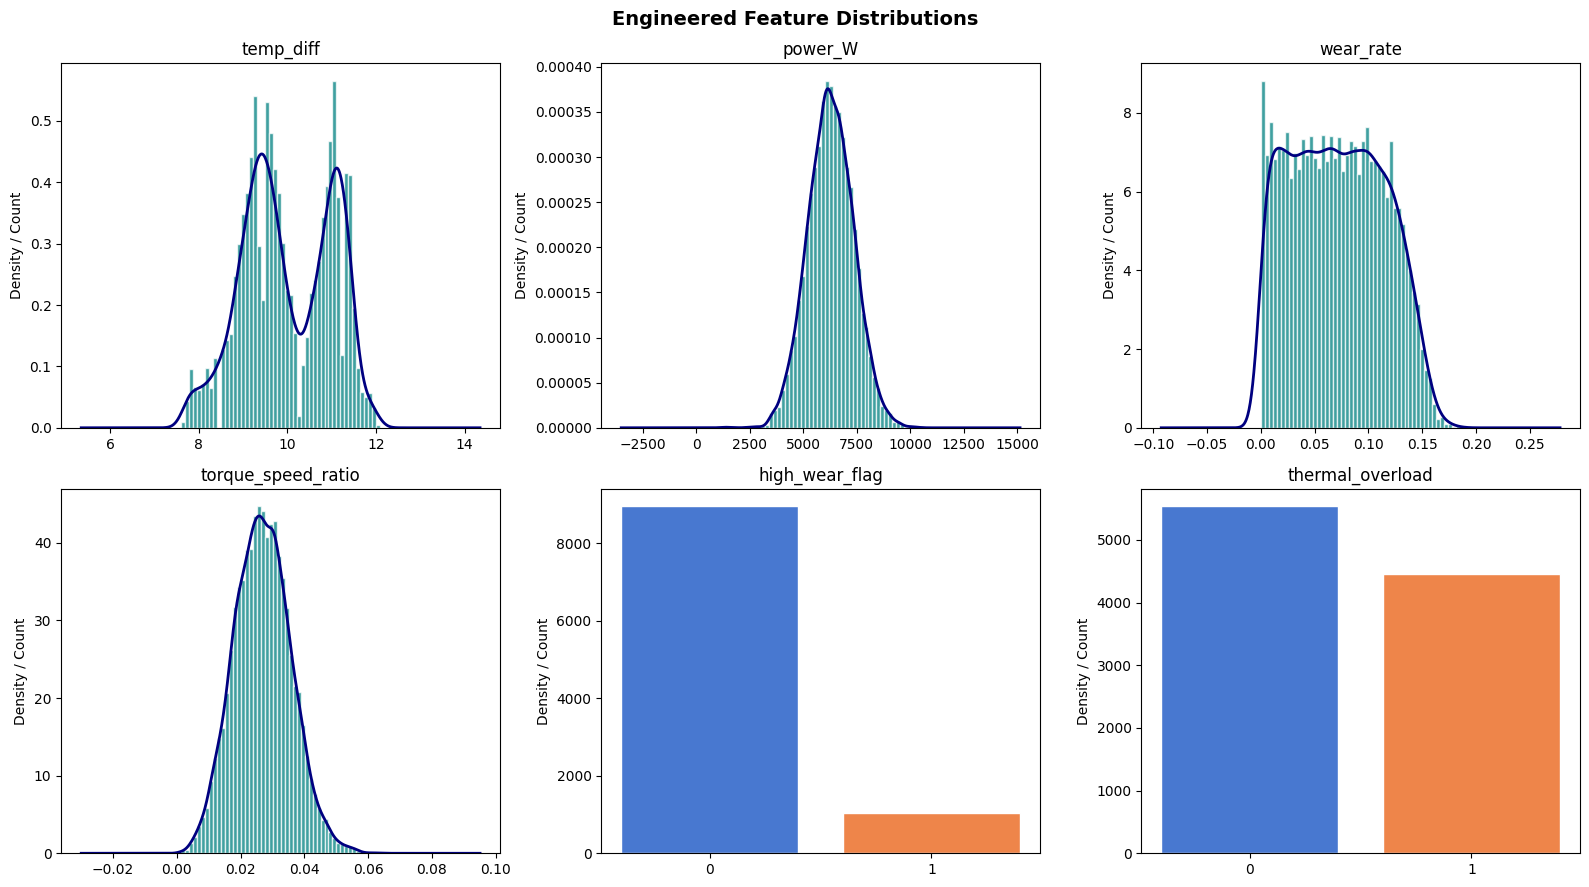

In [139]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

eng_plot_cols = ['temp_diff', 'power_W', 'wear_rate',
                 'torque_speed_ratio', 'high_wear_flag', 'thermal_overload']

for i, col in enumerate(eng_plot_cols):
    ax = axes[i]
    if df_eng[col].nunique() <= 3:           # binary / low-cardinality
        vc = df_eng[col].value_counts()
        ax.bar(vc.index.astype(str), vc.values,
               color=sns.color_palette('muted', len(vc)), edgecolor='white')
        ax.set_title(col)
    else:
        ax.hist(df_eng[col], bins=50, color='teal', alpha=0.75, edgecolor='white', density=True)
        df_eng[col].plot.kde(ax=ax, color='navy', linewidth=2)
        ax.set_title(col)
    ax.set_ylabel('Density / Count')

plt.suptitle('Engineered Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
#plt.savefig('plots/engineered_features.png', bbox_inches='tight')
plt.show()

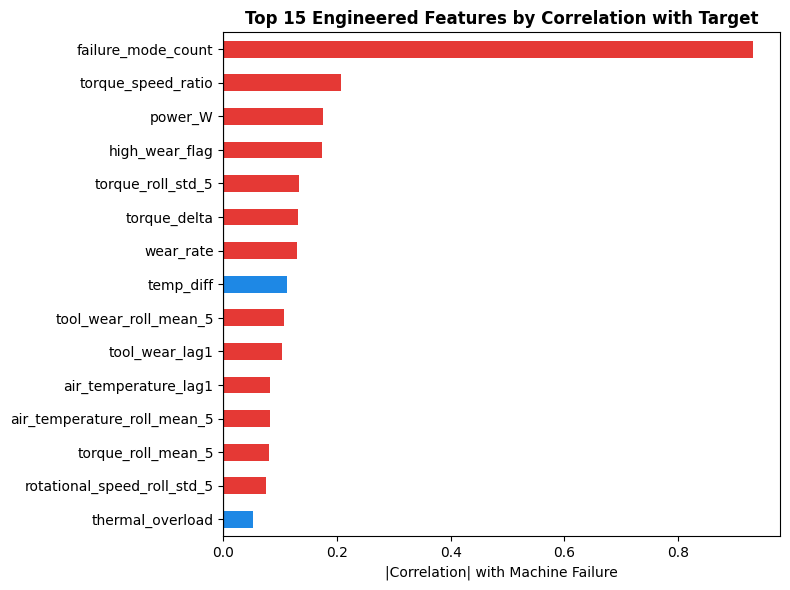

In [142]:
# ── Correlation of engineered features with Machine failure ──────────────────
eng_cols_all = new_feats + ts_features + ['failure_mode_count', 'type_enc']
corr_eng = df_eng[eng_cols_all + ['machine_failure']].corr()['machine_failure'].drop('machine_failure')
corr_eng_sorted = corr_eng.abs().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
corr_eng_sorted.sort_values().plot(kind='barh', ax=ax,
    color=['#E53935' if corr_eng[i]>=0 else '#1E88E5' for i in corr_eng_sorted.sort_values().index])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('|Correlation| with Machine Failure')
ax.set_title('Top 15 Engineered Features by Correlation with Target', fontweight='bold')
plt.tight_layout()
#lt.savefig('plots/10_feature_importance_corr.png', bbox_inches='tight')
plt.show()

In [149]:
# drop failure mode count as it is highly correlated with the target and may leak information
drop_cols = ['failure_mode_count']
df_eng = df_eng.drop(columns=drop_cols)

## Save Data

In [150]:
df_eng.columns

Index(['udi', 'product_id', 'type', 'air_temperature', 'process_temperature',
       'rotational_speed', 'torque', 'tool_wear', 'machine_failure', 'twf',
       'hdf', 'pwf', 'osf', 'rnf', 'type_enc', 'temp_diff', 'power_W',
       'wear_rate', 'torque_speed_ratio', 'high_wear_flag', 'thermal_overload',
       'air_temperature_roll_mean_5', 'air_temperature_roll_std_5',
       'air_temperature_delta', 'air_temperature_lag1',
       'process_temperature_roll_mean_5', 'process_temperature_roll_std_5',
       'process_temperature_delta', 'process_temperature_lag1',
       'rotational_speed_roll_mean_5', 'rotational_speed_roll_std_5',
       'rotational_speed_delta', 'rotational_speed_lag1', 'torque_roll_mean_5',
       'torque_roll_std_5', 'torque_delta', 'torque_lag1',
       'tool_wear_roll_mean_5', 'tool_wear_roll_std_5', 'tool_wear_delta',
       'tool_wear_lag1'],
      dtype='object')

In [152]:
# ── Drop raw identifiers that aren't ML features ────────────────────────────
drop_cols = ['product_id']          # UDI kept as index reference; Type kept for groupby in later notebooks
df_final = df_eng.drop(columns=drop_cols)

print(f"Final dataset shape : {df_final.shape}")
print(f"Columns             : {df_final.columns.tolist()}")

df_final.to_csv('../data/cleaned_data/eda_data.csv', index=False)
print("\n✅  Saved → eda_data.csv")

Final dataset shape : (10000, 40)
Columns             : ['udi', 'type', 'air_temperature', 'process_temperature', 'rotational_speed', 'torque', 'tool_wear', 'machine_failure', 'twf', 'hdf', 'pwf', 'osf', 'rnf', 'type_enc', 'temp_diff', 'power_W', 'wear_rate', 'torque_speed_ratio', 'high_wear_flag', 'thermal_overload', 'air_temperature_roll_mean_5', 'air_temperature_roll_std_5', 'air_temperature_delta', 'air_temperature_lag1', 'process_temperature_roll_mean_5', 'process_temperature_roll_std_5', 'process_temperature_delta', 'process_temperature_lag1', 'rotational_speed_roll_mean_5', 'rotational_speed_roll_std_5', 'rotational_speed_delta', 'rotational_speed_lag1', 'torque_roll_mean_5', 'torque_roll_std_5', 'torque_delta', 'torque_lag1', 'tool_wear_roll_mean_5', 'tool_wear_roll_std_5', 'tool_wear_delta', 'tool_wear_lag1']

✅  Saved → eda_data.csv


In [153]:
# ── Quick final summary ──────────────────────────────────────────────────────
print("=== EDA & Feature Engineering Summary ===")
print(f"Original features      : {len(df.columns)}")
print(f"Engineered features    : {len(df_final.columns)}")
print(f"Rows                   : {len(df_final)}")
print(f"\nFailure class balance  :")
print(df_final['machine_failure'].value_counts(normalize=True).mul(100).round(2).to_string())
print(f"\nNull values remaining  : {df_final.isnull().sum().sum()}")

=== EDA & Feature Engineering Summary ===
Original features      : 14
Engineered features    : 40
Rows                   : 10000

Failure class balance  :
machine_failure
0    96.61
1     3.39

Null values remaining  : 0
